# Continuous-Discrete Extended Kalman Filter: Leaching Reactor

*Generated using Claude Sonnet 5 ([see chat](https://claude.ai/share/03d5becf-101a-4e4d-87f4-99ac93311acf)), then modified for clarity.*

This notebook illustrates how an Extended Kalman Filter (EKF) can estimate unobserved states $\bf x$ from noisy, indirect measurements $\bf y$, given a nonlinear model .

$$\frac{d {\bf x}}{dt} = f({\bf x, u}) + {\bf w}, \qquad {\bf y} = h( {\bf x} ) + {\bf v}$$

A continuous leaching reactor is used as a case study. Dissolved and solid-phase copper concentrations are estimated from measured pH.

Jacobians ($\partial f/\partial x$, $\partial h/\partial x$) are computed automatically with using JAX autodiff. 

All ODEs (the plant, and the EKF's mean/covariance propagation) are integrated with `scipy.integrate.solve_ivp`.


In [3]:
import numpy as np
import jax.numpy as jnp
from jax import jacfwd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
np.random.seed(0)

## Model
A single, well-mixed CSTR leach tank with two separate inlet streams:

$$
\frac{dC_{\textrm{Cu}}^{(s)}}{dt}  =  \frac{Q}{V}\big(C_{\textrm{Cu},in}^{(s)} - C_{\textrm{Cu}}^{(s)}\big) -r \\[8pt]
\frac{dC_{\textrm{Cu}}^{(aq)}}{dt} = -\frac{Q}{V} C_{\textrm{Cu}}^{(aq)} + r \\[8pt]
\frac{dC_{\textrm{H}}}{dt}         =  \frac{Q}{V}\big(C_{\textrm{H},in} - C_{\textrm{H}}\big) - \gamma\, r + q  \\[12pt]
r = k\, C_{\textrm{H}}\, C_{\textrm{Cu}}^{(s)} \\[12pt]
pH = -\log_{10}\!\big(C_{\textrm{H}}\big) + v, \qquad v \sim \mathcal{N}(0, R) 
$$

The relevant component concentrations are:
- Solid-phase (leachable) copper concentration: $C_{\textrm{Cu}}^{(s)}$
- Dissolved copper concentration: $C_{\textrm{Cu}}^{(aq)}$
- Acid (proton) concentration: $C_{\textrm{H}}$

The slurry stream has a constant volumetric flow $Q$ in and out, carrying ore (solid copper) and background acid. The acid dosing stream adds acid at a molar flowrate $q$. We assume the volume of acid dosed is small so it doesn't affect the tank volume $V$, only the acid mass balance. The stoichiometric coefficient for acid consumption per unit Cu dissolved is $\gamma$, and $C_{\textrm{H},in}$ is the acid entering with the slurry feed, and $C_{\textrm{Cu},in}^{(s)}$ the incoming ore's copper content (the feed grade).

## Parameters

All parameters are treated as constant and known.


In [4]:
params = dict(
    Q=1.0,           # slurry volumetric flow, in = out [m^3/min]
    V=10.0,          # reactor volume [m^3]
    k=0.05,          # reaction rate constant [1/(min * (mol/m^3))]
    gamma=1.0,       # stoichiometric acid consumption per unit Cu dissolved
    C_H_in=0.05,     # acid concentration in slurry feed [mol/m^3]
    C_Cu_s_in=8.0,   # solid-phase Cu concentration in feed [mol/m^3]
)
p = tuple(params.values())   # fixed order, unpacked the same way everywhere


## Acid dosing profile

A step change in acid dosing rate, so we can see the filter track a disturbance as well as converge from a bad initial guess.


In [5]:
def u_profile(t):
    return 0.05*50 if t < 60.0 else 0.15   # [mol/min], step at t = 60 min


## Dynamics and measurement functions

Written as plain JAX functions so we can both evaluate them and differentiate them automatically (autodiff) with `jax.jacfwd`.

In [6]:
def f(x, u, p):
    C_Cu, C_H, C_Cu_s = x
    q = u
    Q, V, k, gamma, C_H_in, C_Cu_s_in = p

    r = k * C_H * C_Cu_s

    dC_Cu = -(Q / V) * C_Cu + r
    dC_H = (Q / V) * (C_H_in - C_H) - gamma * r + (q / V)
    dC_Cu_s = (Q / V) * (C_Cu_s_in - C_Cu_s) - r

    return jnp.array([dC_Cu, dC_H, dC_Cu_s])


def h(x):
    C_Cu, C_H, C_Cu_s = x
    return jnp.array([-jnp.log10(C_H)])


### Autodiff Jacobians

Instead of hand-deriving $\partial f_c/\partial x$ and $\partial h/\partial x$,
we let JAX compute them exactly at any point via forward-mode autodiff.


In [7]:
A_func = jacfwd(f, argnums=0)   # df_c/dx -> 3x3, via autodiff
C_func = jacfwd(h, argnums=0)     # dh/dx   -> 1x3, via autodiff


## Simulate the true plant and generate noisy pH measurements

The true trajectory is obtained by integrating $\frac{d {\bf x}}{dt} = f({\bf x, u})$ with `solve_ivp` (no process noise — the model is assumed exact). pH is then sampled at discrete times $t_k$ and corrupted with measurement noise.


In [8]:
def plant_ode(t, x, p):
    # Converts jnp.array to np.array for solve_ivp
    return np.array(f(jnp.array(x), u_profile(t), p)) 

def plant_measurements(x_true, t_grid, t_meas, R): 
    # Generates noisy measurements from the true state trajectory
    idx_meas = np.searchsorted(t_grid, t_meas)
    sigma = np.sqrt(R[0, 0])
    y_true = np.array([h(jnp.array(x_true[idx]))[0] for idx in idx_meas])
    return y_true + sigma * np.random.randn(len(t_meas))


## Hybrid Extended Kalman Filter

Two steps, repeated at each measurement time $t_k$:

1. Predict: integrate the nonlinear mean $\frac{d {\bf \hat x}}{dt} = f({\bf \hat x, u})$
   and the covariance Riccati equation
    $$ \frac{dP}{dt} = AP + P A^\top + Q, \qquad A(t) = \left.\frac{\partial f}{\partial x}\right|_{\hat x(t), u(t)}$$
   forward between samples. We integrate $x$ and $P$ *jointly* as one
   augmented ODE with `solve_ivp`, so the autodiff Jacobian $A(t)$ is
   re-evaluated at every internal step the adaptive integrator takes.

2. Update: the standard discrete Kalman update, using the autodiff measurement Jacobian $C = \partial h/\partial x$.

The code below is a general EKF implementation and not limited to the specific case study.

In [9]:
def ekf_augmented_ode(t, z, u, p, Q, n):
    x, P = z[:n], z[n:].reshape(n, n)
    A = np.array(A_func(jnp.array(x), u, p))
    dx = np.array(f(jnp.array(x), u, p))
    dP = A @ P + P @ A.T + Q
    return np.concatenate([dx, dP.flatten()])
    
def ekf_predict(x_hat, P, u, p, Q, dt):
    n = len(x_hat)
    z0 = np.concatenate([x_hat, P.flatten()])
    sol = solve_ivp(ekf_augmented_ode, (0.0, dt), z0, args=(u, p, Q, n))
    z_end = sol.y[:, -1]
    return z_end[:n], z_end[n:].reshape(n, n)

def ekf_update(x_pred, P_pred, y, R):
    C = np.array(C_func(jnp.array(x_pred)))    
    y_pred = np.array(h(jnp.array(x_pred)))

    S = C @ P_pred @ C.T + R
    K = P_pred @ C.T @ np.linalg.inv(S)

    x_upd = x_pred + (K @ (y - y_pred)).flatten()
    P_upd = (np.eye(len(x_pred)) - K @ C) @ P_pred
    return x_upd, P_upd


## Run the scenario

The EKF is deliberately started from a wrong initial guess, to show convergence in addition to disturbance tracking.


In [27]:
# Specify model initial conditions and simulation parameters
x0_true = np.array([2.0, 0.6, 6.0])       # true initial state
T_final = 180.0                            # minutes
t_grid = np.linspace(0.0, T_final, 2000)   # fine grid, for plotting "truth"
t_meas = np.arange(0.0, T_final + 2.0, 2.0)  # pH sampled every 2 min

# Define noise covariances
R = np.array([[0.05]])                     # pH measurement noise variance
Q = np.diag([1e-2, 1e-2, 1e-2])           # EKF process noise (tuning knob)

# Simulate the "true" plant dynamics and generate noisy measurements
sol = solve_ivp(plant_ode, (t_grid[0], t_grid[-1]), x0_true, t_eval=t_grid, args=(p,))
x_true = sol.y.T
y_meas = plant_measurements(x_true, t_grid, t_meas, R)

# Run the EKF with an initial guess and covariance
n = len(x0_true)
x_est = np.zeros((len(t_meas), n))
P_est = np.zeros((len(t_meas), n, n))

x_est[0], P_est[0] = np.array([0.0, 2, 1.0]), np.diag([1.0, 0.1, 4.0])    # deliberately wrong EKF guess

for k in range(1, len(t_meas)):
    dt = t_meas[k] - t_meas[k - 1]
    u = u_profile(t_meas[k - 1])

    x_pred, P_pred = ekf_predict(x_est[k-1], P_est[k-1], u, p, Q, dt)
    x_est[k], P_est[k] = ekf_update(x_pred, P_pred, np.array([y_meas[k]]), R)

## Plot results

State estimates vs. truth, with $\pm 2\sigma$ confidence bands, plus the noisy pH measurements the filter actually sees.


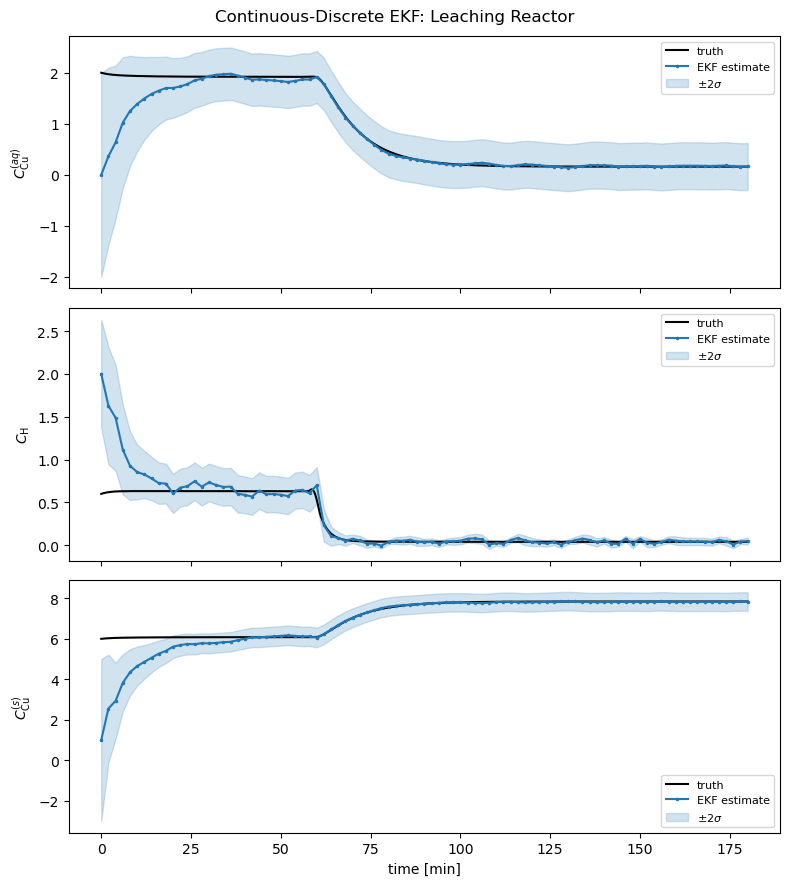

In [28]:
labels = [r"$C_{\text{Cu}}^{(aq)}$", r"$C_{\text{H}}$", r"$C_{\text{Cu}}^{(s)}$"]
fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
for i in range(3):
    axes[i].plot(t_grid, x_true[:, i], "k-", label="truth")
    axes[i].plot(t_meas, x_est[:, i], "C0.-", label="EKF estimate", markersize=3)
    std = np.sqrt(P_est[:, i, i])
    axes[i].fill_between(t_meas, x_est[:, i] - 2 * std, x_est[:, i] + 2 * std,
                          color="C0", alpha=0.2, label=r"$\pm 2\sigma$")
    axes[i].set_ylabel(labels[i])
    axes[i].legend(loc="best", fontsize=8)
axes[-1].set_xlabel("time [min]")
fig.suptitle("Continuous-Discrete EKF: Leaching Reactor")
fig.tight_layout()


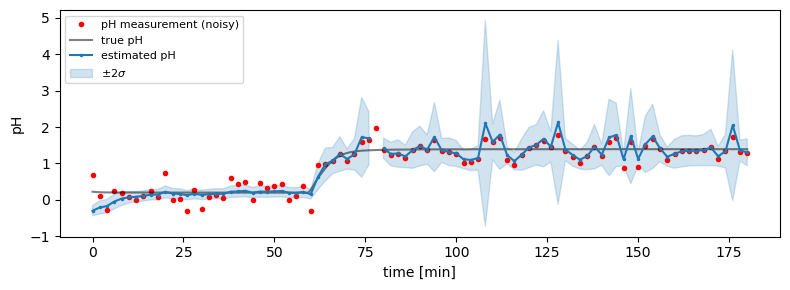

In [30]:
fig2, ax2 = plt.subplots(figsize=(8, 3))
ax2.plot(t_meas, y_meas, "r.", label="pH measurement (noisy)")
y_true_full = np.array([h(jnp.array(x_true[i]))[0] for i in range(len(t_grid))])
ax2.plot(t_grid, y_true_full, "k-", alpha=0.5, label="true pH")

# Compute estimated pH mean and variance via measurement Jacobian linearization
y_est = np.array([h(jnp.array(x_est[k]))[0] for k in range(len(t_meas))])
var_y_est = np.array([
    (np.array(C_func(jnp.array(x_est[k]))) @ P_est[k] @ np.array(C_func(jnp.array(x_est[k]))).T)[0, 0]
    for k in range(len(t_meas))
])
std_y_est = np.sqrt(var_y_est)

ax2.plot(t_meas, y_est, "C0.-", label="estimated pH", markersize=3)
ax2.fill_between(t_meas, y_est - 2 * std_y_est, y_est + 2 * std_y_est,
                 color="C0", alpha=0.2, label=r"$\pm 2\sigma$")

ax2.set_xlabel("time [min]")
ax2.set_ylabel("pH")
ax2.legend(loc="best", fontsize=8)
fig2.tight_layout()